Question 8 )

Part A)

You are tasked with designing a multimodal AI system that can:

a. Classify images

b. Answer questions about images

c. Perform zero-shot classification on new categories

Explain how Zero-Shot Learning enables classification of unseen categories.

**Your answer must include:**

d. Role of Natural Language Inference (NLI)

e. How models like BART MNLI perform zero-shot classification by
using a trick we discussed in class

f. Limitations of zero-shot approaches

##Answer:

Zero-Shot Learning (ZSL) is a paradigm that enables models to recognize objects or categories they have never encountered during training. This is achieved by leveraging auxiliary information that connects seen and unseen classes, often in the form of natural language descriptions or semantic embeddings.

Here's a breakdown of how it enables classification of unseen categories, including the specific points you requested:

**How Zero-Shot Learning Enables Classification of Unseen Categories:**

Traditional machine learning models require examples of each class to learn how to classify them. ZSL overcomes this limitation by transferring knowledge from seen classes to unseen classes through a shared semantic space. Instead of directly learning a mapping from features to labels, ZSL learns a mapping from features to a semantic representation (e.g., word embeddings, attribute vectors) of the classes. When a new, unseen class appears, its semantic representation can be used to classify it, even without any training examples of that specific class.

**d. Role of Natural Language Inference (NLI):**

Natural Language Inference (NLI), also known as Recognizing Textual Entailment (RTE), plays a crucial role in many ZSL approaches, especially those that leverage textual descriptions of classes. NLI models are trained to determine the relationship between two sentences (a premise and a hypothesis), classifying it as entailment, contradiction, or neutral. In the context of ZSL:

*   **Premise:** This often describes the input (e.g., an image caption, a description of an object in the image).
*   **Hypothesis:** This is usually a statement about a potential class (e.g., "This is a photo of a cat," or "The object in the image is a chair").

By framing classification as an NLI problem, the model can infer whether the input 'entails' a particular class label, even if it has never seen examples of that label before. This allows for a flexible and interpretable way to associate visual features with semantic concepts.

**e. How models like BART MNLI perform zero-shot classification by using a trick we discussed in class:**

Models like BART, when fine-tuned on the Multi-Genre Natural Language Inference (MNLI) dataset, can perform zero-shot classification using a clever 'prompting' or 'textual entailment' trick. Here's how it works:

1.  **NLI Training:** The BART model is initially trained on the MNLI dataset, learning to distinguish between entailment, contradiction, and neutrality for pairs of sentences.
2.  **Zero-Shot Adaptation:** To classify an input (e.g., a piece of text for text classification, or a text description derived from an image for image classification), the process is as follows:
    *   **Premise Construction:** The input text (or its description) becomes the **premise**.
    *   **Hypothesis Generation:** For each potential class label (including unseen ones), a **hypothesis** is constructed. This usually takes the form of a templated sentence, such as: "This text is about [CLASS_LABEL]." or "This image depicts a [CLASS_LABEL]."
    *   **NLI Inference:** The BART MNLI model then evaluates each (premise, hypothesis) pair. It outputs probabilities for entailment, contradiction, and neutral for each pair.
    *   **Classification:** The class label whose hypothesis yields the highest probability of **entailment** with the premise is chosen as the predicted class. Because the NLI model generalizes well to new sentence structures and concepts, it can 'entail' hypotheses for unseen class labels as long as their semantic meaning can be understood within the context of the NLI training.

This 'trick' transforms a classification problem into an NLI problem, leveraging the NLI model's ability to understand semantic relationships between sentences to classify new, unseen categories.

**f. Limitations of zero-shot approaches:**

Despite their power, zero-shot learning approaches have several limitations:

1.  **Reliance on Semantic Descriptions:** ZSL performance heavily depends on the quality and completeness of the semantic descriptions or attributes provided for both seen and unseen classes. Poor or ambiguous descriptions can lead to misclassification.
2.  **"Generalized Zero-Shot Learning" Challenge:** Standard ZSL assumes that during testing, only unseen classes will appear. In a more realistic "generalized ZSL" setting, both seen and unseen classes can appear. Many ZSL models struggle in this scenario, often exhibiting a bias towards seen classes because they have direct training examples.
3.  **Semantic Gap:** There can be a significant "semantic gap" between the visual features extracted from an image and the semantic features (e.g., word embeddings) used to describe classes. Bridging this gap effectively is a major challenge.
4.  **Novelty Detection:** ZSL models are designed to classify into known (seen or unseen) categories. They typically don't perform well at detecting truly novel concepts that fall outside the defined semantic space, or at identifying when an input doesn't belong to any of the predefined classes.
5.  **Ambiguity and Fine-Grained Distinctions:** When unseen classes are very similar to each other or to seen classes, the semantic descriptions might not be sufficient to make fine-grained distinctions, leading to errors.
6.  **Computational Cost:** For a large number of potential unseen classes, generating and evaluating a hypothesis for each can be computationally intensive, especially if the underlying NLI model is large.

##part b)
Compare the following architectures:

• CNN

• Vision Transformer (ViT)

• Large Language Models (LLMs)

Your comparison must include:

a. Input representation differences

b. Feature extraction mechanism


c. Scalability and performance

d. Suitability for multimodal tasks

## Answer:

### Comparison of Architectures: CNN, Vision Transformer (ViT), and Large Language Models (LLMs)

---

**a. Input Representation Differences**

*   **Convolutional Neural Networks (CNN):** Images are treated as 2D grids of pixels. Input is typically a 3D tensor (height, width, channels).

*   **Vision Transformer (ViT):** Images are first broken down into a sequence of fixed-size patches (tokens). Each patch is then linearly embedded, and position embeddings are added to retain spatial information, forming a 1D sequence of vectors.

*   **Large Language Models (LLMs):** Primarily designed for sequential text data. Input is a sequence of tokens (words, subwords) represented as embeddings. Can process multimodal inputs (image, audio) by converting them into a tokenized sequential representation compatible with the model's text processing pipeline.

---

**b. Feature Extraction Mechanism**

*   **Convolutional Neural Networks (CNN):** Uses convolutional layers to extract hierarchical features. Small filters (kernels) slide over the input, learning local patterns (edges, textures) and building up to more complex global features (objects, shapes) through pooling and deeper layers.

*   **Vision Transformer (ViT):** Relies on self-attention mechanisms (Multi-Head Self-Attention). Each patch token attends to all other patch tokens to capture global dependencies and relationships across the entire image. This allows it to weigh the importance of different parts of the image for feature representation.

*   **Large Language Models (LLMs):** Uses self-attention (Transformer encoder-decoder architecture) to capture long-range dependencies and contextual relationships within sequential input. Tokens attend to other tokens in the sequence to build rich, context-aware representations.

---

**c. Scalability and Performance**

*   **Convolutional Neural Networks (CNN):** Highly efficient for image data. Performance often saturates beyond a certain model size. Generally requires more data augmentation to achieve high performance on smaller datasets. Computation scales with image size and number of filters.

*   **Vision Transformer (ViT):** Shows strong scalability with model size and data. Requires large datasets for pre-training to achieve superior performance compared to CNNs, especially on image recognition tasks. Can be computationally expensive due to quadratic complexity of self-attention with respect to sequence length, though optimizations exist.

*   **Large Language Models (LLMs):** Excellent scalability with model size (billions of parameters) and vast amounts of text data. Performance continues to improve with more data and larger models. Highly computationally intensive to train due to sheer size. Inference can also be demanding, but can be optimized.

---

**d. Suitability for Multimodal Tasks**

*   **Convolutional Neural Networks (CNN):** Traditionally unimodal (vision). Multimodality often achieved by combining CNN features with other modalities (e.g., text embeddings) in later layers or through specialized architectures (e.g., CNN+RNN for image captioning).

*   **Vision Transformer (ViT):** Originally vision-specific, but the core Transformer architecture is inherently suited for sequences. Can be extended to multimodality by treating different modalities (e.g., image patches, text tokens) as a unified sequence of tokens, allowing the self-attention mechanism to learn cross-modal relationships. Examples include models like CoCa.

*   **Large Language Models (LLMs):** Excellent for multimodal tasks, especially when text is a primary component. Can integrate other modalities (images, audio) by converting them into a tokenized representation (e.g., visual tokens from a vision encoder) that can be processed alongside text tokens. The unified token space allows for powerful cross-modal reasoning and generation. Examples include Flamingo, GPT-4V, Gemini.

## Part C)
####Design a multimodal AI pipeline integrating:

####• Vision Transformer (for image understanding)
####• LLM (for reasoning and generation)
####Your design must include:
####a. Image encoding process
####b. Text generation pipeline
####c. How cross-modal understanding is achieved
####Additionally:
####d. Suggest how this system can be extended using:
*  RAG
*  External knowledge sources



## Answer: Multimodal AI Pipeline Design

We will design a pipeline that leverages a Vision Transformer (ViT) to process visual information and a Large Language Model (LLM) to perform reasoning, generate textual responses, and integrate cross-modal understanding.

### Pipeline Overview:

1.  **Image Input:** An image is provided to the system.
2.  **Image Encoding (ViT):** The ViT processes the image and extracts meaningful visual features.
3.  **Visual Feature-to-Textual Token Conversion:** The visual features are transformed into a format that the LLM can understand (e.g., visual tokens or a concise textual description).
4.  **Textual Input/Prompting (LLM):** The user's query (if any) and the converted visual information are fed into the LLM as a combined prompt.
5.  **Reasoning and Generation (LLM):** The LLM processes this multimodal input, performs reasoning, and generates a coherent textual response.

### Detailed Design Components:

**a. Image Encoding Process (using Vision Transformer - ViT):**

1.  **Image Patching:** The input image is divided into a grid of fixed-size, non-overlapping patches (e.g., 16x16 pixels).
2.  **Linear Embedding:** Each image patch is flattened and linearly projected into a lower-dimensional embedding space. This creates a sequence of patch embeddings.
3.  **Positional Embeddings:** To preserve spatial information, learnable positional embeddings are added to each patch embedding. This allows the model to understand the relative location of each patch within the image.
4.  **Transformer Encoder:** The sequence of patch embeddings (plus a special `[CLS]` token for global image representation) is fed into a standard Transformer encoder architecture. This encoder consists of multiple layers of multi-head self-attention and feed-forward networks.
    *   **Self-Attention:** The self-attention mechanism allows each patch to attend to all other patches, capturing global relationships and dependencies across the entire image. This is crucial for understanding context and relationships between different parts of the image.
5.  **Feature Extraction:** The output of the ViT's Transformer encoder (specifically, the `[CLS]` token's embedding or an aggregated representation of all patch embeddings) serves as a rich, context-aware visual feature representation of the input image.

**b. Text Generation Pipeline (using LLM):**

1.  **Input Tokenization:** The user's natural language query (e.g., "What is in this image?", "Describe the scene") is tokenized into a sequence of subword units (tokens).
2.  **Visual Token Integration:** The encoded visual features from the ViT need to be integrated into the LLM's input sequence. This can be achieved through various methods:
    *   **Projection Layer:** The ViT's output feature vector is passed through a projection layer (e.g., a simple linear layer) to transform it into the same embedding space as the LLM's textual tokens. These projected visual features are then prepended or inserted into the LLM's token sequence.
    *   **Q-Former (or similar):** A dedicated module (like the Q-Former in Flamingo models) can be used to query the visual features from the ViT using learned query tokens. The output of the Q-Former then forms a set of visual tokens that are concatenated with the textual tokens for the LLM.
    *   **Captioning/Description Generation:** An intermediate module might generate a textual description of the image from the ViT features, which is then fed as text to the LLM. (Less ideal for direct cross-modal understanding, but simpler).
3.  **LLM Processing:** The combined sequence of textual and visual tokens is fed into the LLM (typically a decoder-only Transformer). The LLM's self-attention mechanisms allow it to attend to both visual and textual tokens, enabling joint reasoning.
4.  **Text Generation:** Based on the integrated input, the LLM generates a response, token by token, leveraging its vast knowledge base and understanding of the prompt's context (visual and textual).

**c. How Cross-Modal Understanding is Achieved:**

Cross-modal understanding is primarily achieved through the **unified embedding space and the attention mechanisms within the LLM (or a dedicated cross-attention module before the LLM)**:

*   **Shared Representation Space:** The critical step is to map the visual features from the ViT into a representation space that is compatible with the LLM's textual embeddings. This allows the LLM to treat visual information and textual information as part of a single, coherent input stream.
*   **Cross-Attention/Self-Attention in LLM:**
    *   When visual tokens are directly integrated into the LLM's input sequence, the LLM's **self-attention layers** can attend across all tokens—both textual and visual. This means that when the LLM is generating a word related to an object, it can simultaneously attend to the visual features corresponding to that object in the image. This enables the LLM to ground its textual generation in the visual evidence.
    *   In some architectures (e.g., early multimodal models), dedicated **cross-attention layers** might be used, where the textual tokens query the visual features, allowing information to flow from one modality to the other explicitly.
*   **Pre-training on Multimodal Data:** The success of these systems relies heavily on pre-training on massive multimodal datasets (image-text pairs). During pre-training, the model learns to align visual concepts with their textual descriptions, building an internal representation that captures the relationships between the two modalities.

### d. How this system can be extended using:

**1. Retrieval-Augmented Generation (RAG):**

RAG can significantly enhance the system's ability to answer factual questions and provide up-to-date information by integrating external knowledge beyond what's stored in the LLM's parameters.

*   **Process:**
    1.  **Multimodal Query Formulation:** The initial user query and the image features (or a preliminary LLM-generated description of the image) are combined to form a richer query.
    2.  **Retrieval:** This multimodal query is used to search a vast external knowledge base (e.g., Wikipedia, research papers, a proprietary database). The retrieval system (e.g., using vector embeddings and similarity search) identifies and fetches relevant documents or passages.
    3.  **Augmented Prompt:** The retrieved relevant information is then appended to the original multimodal prompt as additional context.
    4.  **LLM Generation:** The LLM receives this augmented prompt (user query + visual features + retrieved context) and generates a more informed and accurate response.

*   **Benefits:** Reduces hallucinations, provides access to up-to-date information, enhances factual accuracy, allows citations to sources.

**2. External Knowledge Sources:**

Beyond RAG, various external knowledge sources can be integrated:

*   **Structured Knowledge Bases (KGs):**
    *   **Integration:** After the LLM processes the image and query, it could query a Knowledge Graph (e.g., Wikidata, ConceptNet) to retrieve structured facts, relationships, or attributes related to entities identified in the image or query. This can be done by converting parts of the LLM's intermediate reasoning into SPARQL queries or similar.
    *   **Example:** If the image shows a specific animal, the system could query a KG for its habitat, diet, or conservation status.
*   **APIs and Web Services:**
    *   **Integration:** The LLM can be equipped with `tool-use` capabilities, allowing it to call external APIs based on its understanding of the user's request and the image content. For example, if the image contains a product, the LLM could call a shopping API to find pricing information.
    *   **Example:** An image of a landmark could trigger an API call to a travel guide for historical facts or nearby attractions.
*   **Domain-Specific Databases:**
    *   **Integration:** For specialized applications (e.g., medical imaging, manufacturing defect detection), the system could access domain-specific databases to retrieve highly relevant, expert-curated information that the general LLM might not possess.
    *   **Example:** An image of a medical scan could be analyzed by the ViT, and the LLM could then query a medical database for potential diagnoses or treatment protocols based on the visual findings.

### Illustrative Example: Image Patching for Vision Transformer

In [1]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Helper function to display image
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

Content-Type received: image/jpeg
Sample image downloaded and opened successfully.


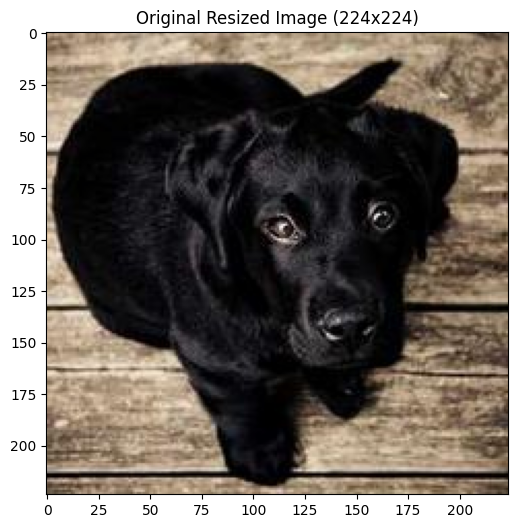

In [4]:
import requests
from io import BytesIO
from PIL import Image, UnidentifiedImageError

# Use a more reliable sample image URL from Lorem Picsum
img_url = 'https://picsum.photos/id/237/224/224' # This directly provides a 224x224 image

img = None # Initialize img to None

print("Downloading a sample image...")
try:
    response = requests.get(img_url, timeout=10) # Added timeout
    response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)

    content_type = response.headers.get('Content-Type', '')
    print(f"Content-Type received: {content_type}")

    if 'image' in content_type: # Check if the content type indicates an image
        img = Image.open(BytesIO(response.content))
        print("Sample image downloaded and opened successfully.")
    else:
        print(f"Received content is not an image (Content-Type: {content_type}). Attempting fallback.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
except UnidentifiedImageError as e:
    print(f"Error opening image from downloaded content: {e}")
except Exception as e:
    print(f"An unexpected error occurred during image loading: {e}")

if img is None:
    print("Could not load image from URL. Falling back to a dummy black image.")
    img = Image.new('RGB', (224, 224), color='black') # Create a dummy black image
    print("Dummy black image created.")

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Ensure it's 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

original_image_tensor = transform(img)

plt.figure(figsize=(6,6))
imshow(original_image_tensor, title='Original Resized Image (224x224)')
plt.show()

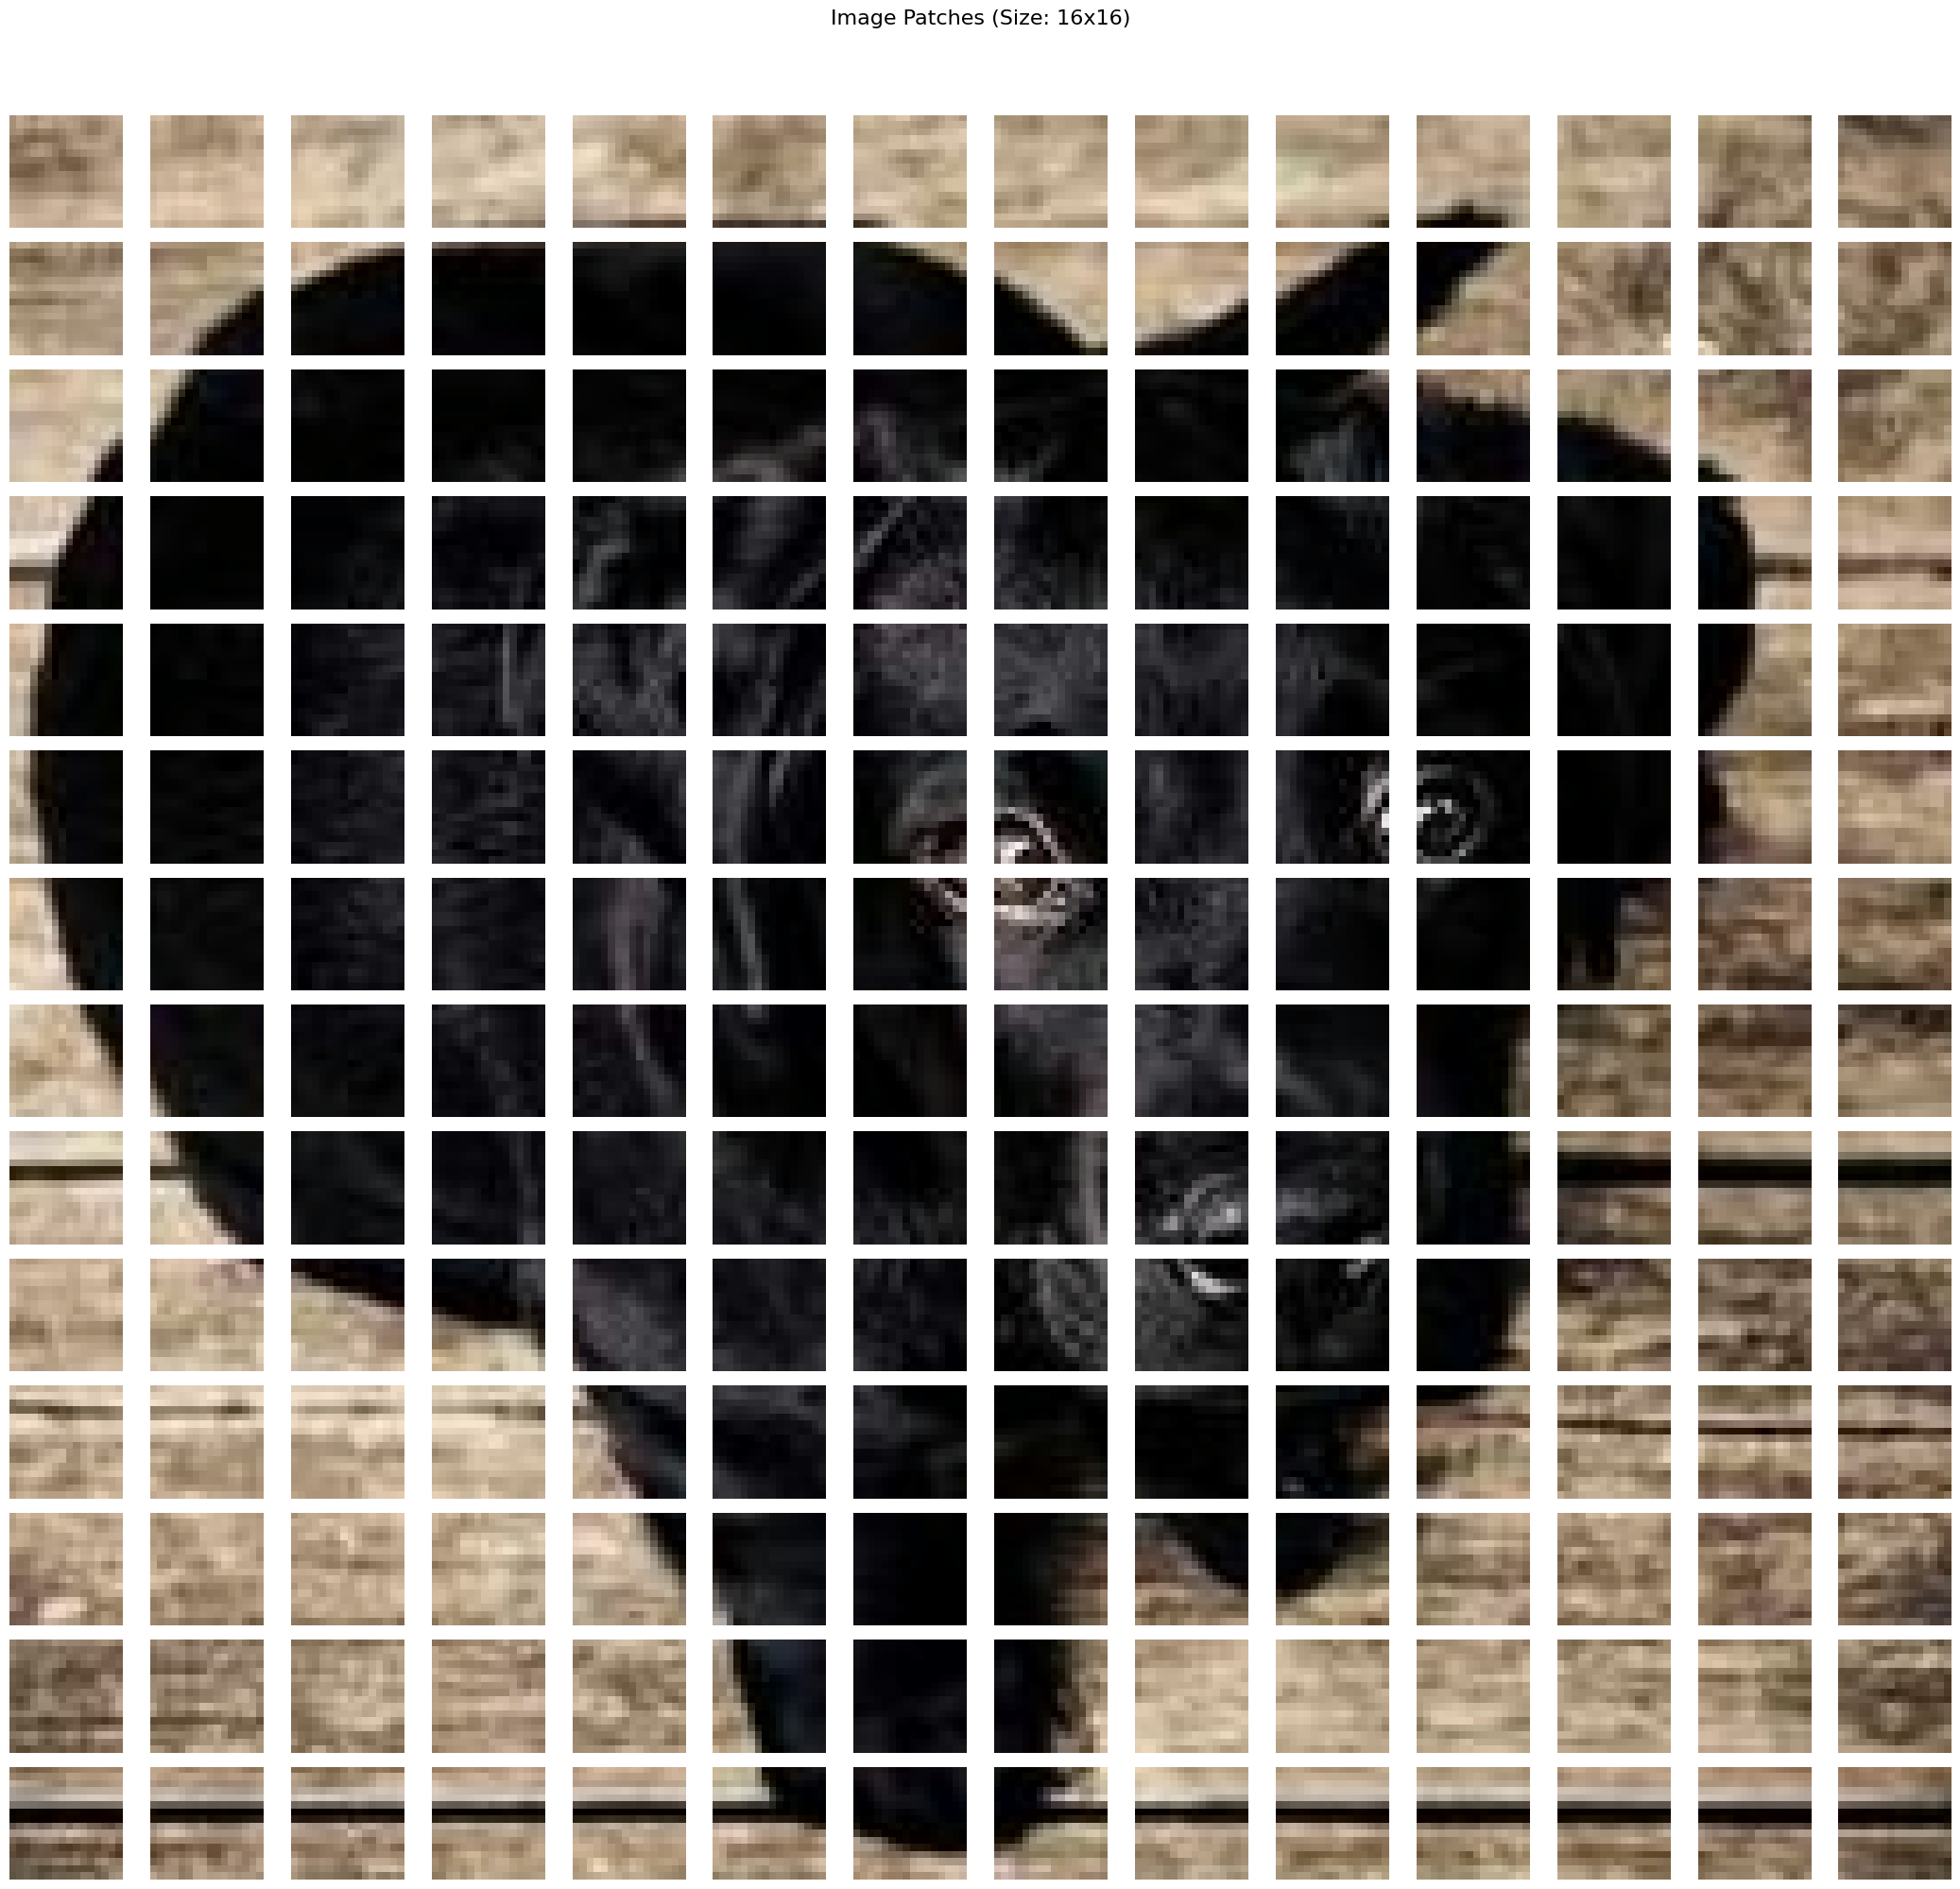

Original image dimensions: 224x224
Patch size: 16x16
Number of patches (height x width): 14 x 14 = 196
Shape of a single patch tensor: torch.Size([3, 16, 16])


In [5]:
# 2. Implement Image Patching

# Define patch size (e.g., 16x16 for ViT-base)
patch_size = 16

# Ensure original_image_tensor is defined
if 'original_image_tensor' not in globals():
    # This block will execute if the preceding cell (bae2fdb5) did not successfully define original_image_tensor
    print("Warning: 'original_image_tensor' not found in global scope. Creating a dummy black tensor for patching demonstration.")
    # Assuming torch and transforms are imported in a previous cell (e.g., 9b960f05)
    # If not, add imports here:
    import torch
    import torchvision.transforms as transforms

    dummy_img = torch.zeros(3, 224, 224) # RGB, 224x224
    # Re-create transform with normalization as it's needed to process the dummy image
    transform = transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    original_image_tensor = transform(dummy_img)


# Unnormalize the image tensor for better visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_to_patch = inv_normalize(original_image_tensor).cpu()

c, h, w = img_to_patch.shape

# Calculate number of patches in height and width
num_patches_h = h // patch_size
num_patches_w = w // patch_size

# Create a figure to display patches
fig, axes = plt.subplots(num_patches_h, num_patches_w, figsize=(num_patches_w * 1.5, num_patches_h * 1.5))
fig.suptitle(f'Image Patches (Size: {patch_size}x{patch_size})', fontsize=16)

patch_tensors = []
for i in range(num_patches_h):
    for j in range(num_patches_w):
        # Extract patch
        patch = img_to_patch[:, i * patch_size:(i + 1) * patch_size, j * patch_size:(j + 1) * patch_size]
        patch_tensors.append(patch)

        # Display patch
        ax = axes[i, j]
        ax.imshow(patch.permute(1, 2, 0).numpy())
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Original image dimensions: {h}x{w}")
print(f"Patch size: {patch_size}x{patch_size}")
print(f"Number of patches (height x width): {num_patches_h} x {num_patches_w} = {len(patch_tensors)}")
print(f"Shape of a single patch tensor: {patch_tensors[0].shape}")